# Week 2 – Data Exploration and Preprocessing

## Student Performance Prediction

This notebook performs Exploratory Data Analysis (EDA) and data preprocessing on the student performance dataset.

### Objectives
- Understand the structure of the dataset
- Identify numerical and categorical features
- Check missing values and duplicates
- Analyze distributions and relationships
- Detect potential outliers
- Study correlations
- Prepare a preprocessing pipeline
- Prevent data leakage
- Create data suitable for machine learning


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", None)

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
df = pd.read_csv("../data/student-mat.csv", sep=";")

print("Dataset loaded successfully")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully
Shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 395
Number of columns: 33


In [6]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [7]:
df.dtypes

school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
dtype: object

In [8]:
df.nunique().sort_values()

school         2
sex            2
address        2
famsize        2
Pstatus        2
schoolsup      2
paid           2
famsup         2
nursery        2
romantic       2
internet       2
higher         2
activities     2
guardian       3
studytime      4
traveltime     4
failures       4
reason         4
freetime       5
Mjob           5
Medu           5
Fjob           5
Fedu           5
famrel         5
health         5
goout          5
Dalc           5
Walc           5
age            8
G1            17
G2            17
G3            18
absences      34
dtype: int64

In [9]:
missing = df.isnull().sum()

missing_percentage = (missing / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing,
    "Missing Percentage": missing_percentage
})

missing_summary.sort_values(
    by="Missing Count",
    ascending=False
)

,Missing Count,Missing Percentage
school,0,0.0
sex,0,0.0
age,0,0.0
address,0,0.0
famsize,0,0.0
Pstatus,0,0.0
Medu,0,0.0
Fedu,0,0.0
Mjob,0,0.0
Fjob,0,0.0


In [10]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [11]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

categorical_columns = df.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numerical columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

Categorical columns:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


In [12]:
target = "G3"

print("Target variable:", target)

df[target].describe()

Target variable: G3


count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64

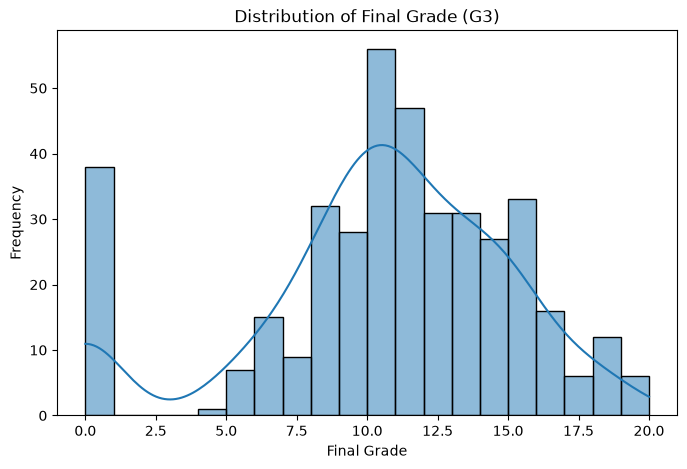

In [13]:
plt.figure(figsize=(8, 5))

sns.histplot(df["G3"], bins=20, kde=True)

plt.title("Distribution of Final Grade (G3)")
plt.xlabel("Final Grade")
plt.ylabel("Frequency")

plt.show()

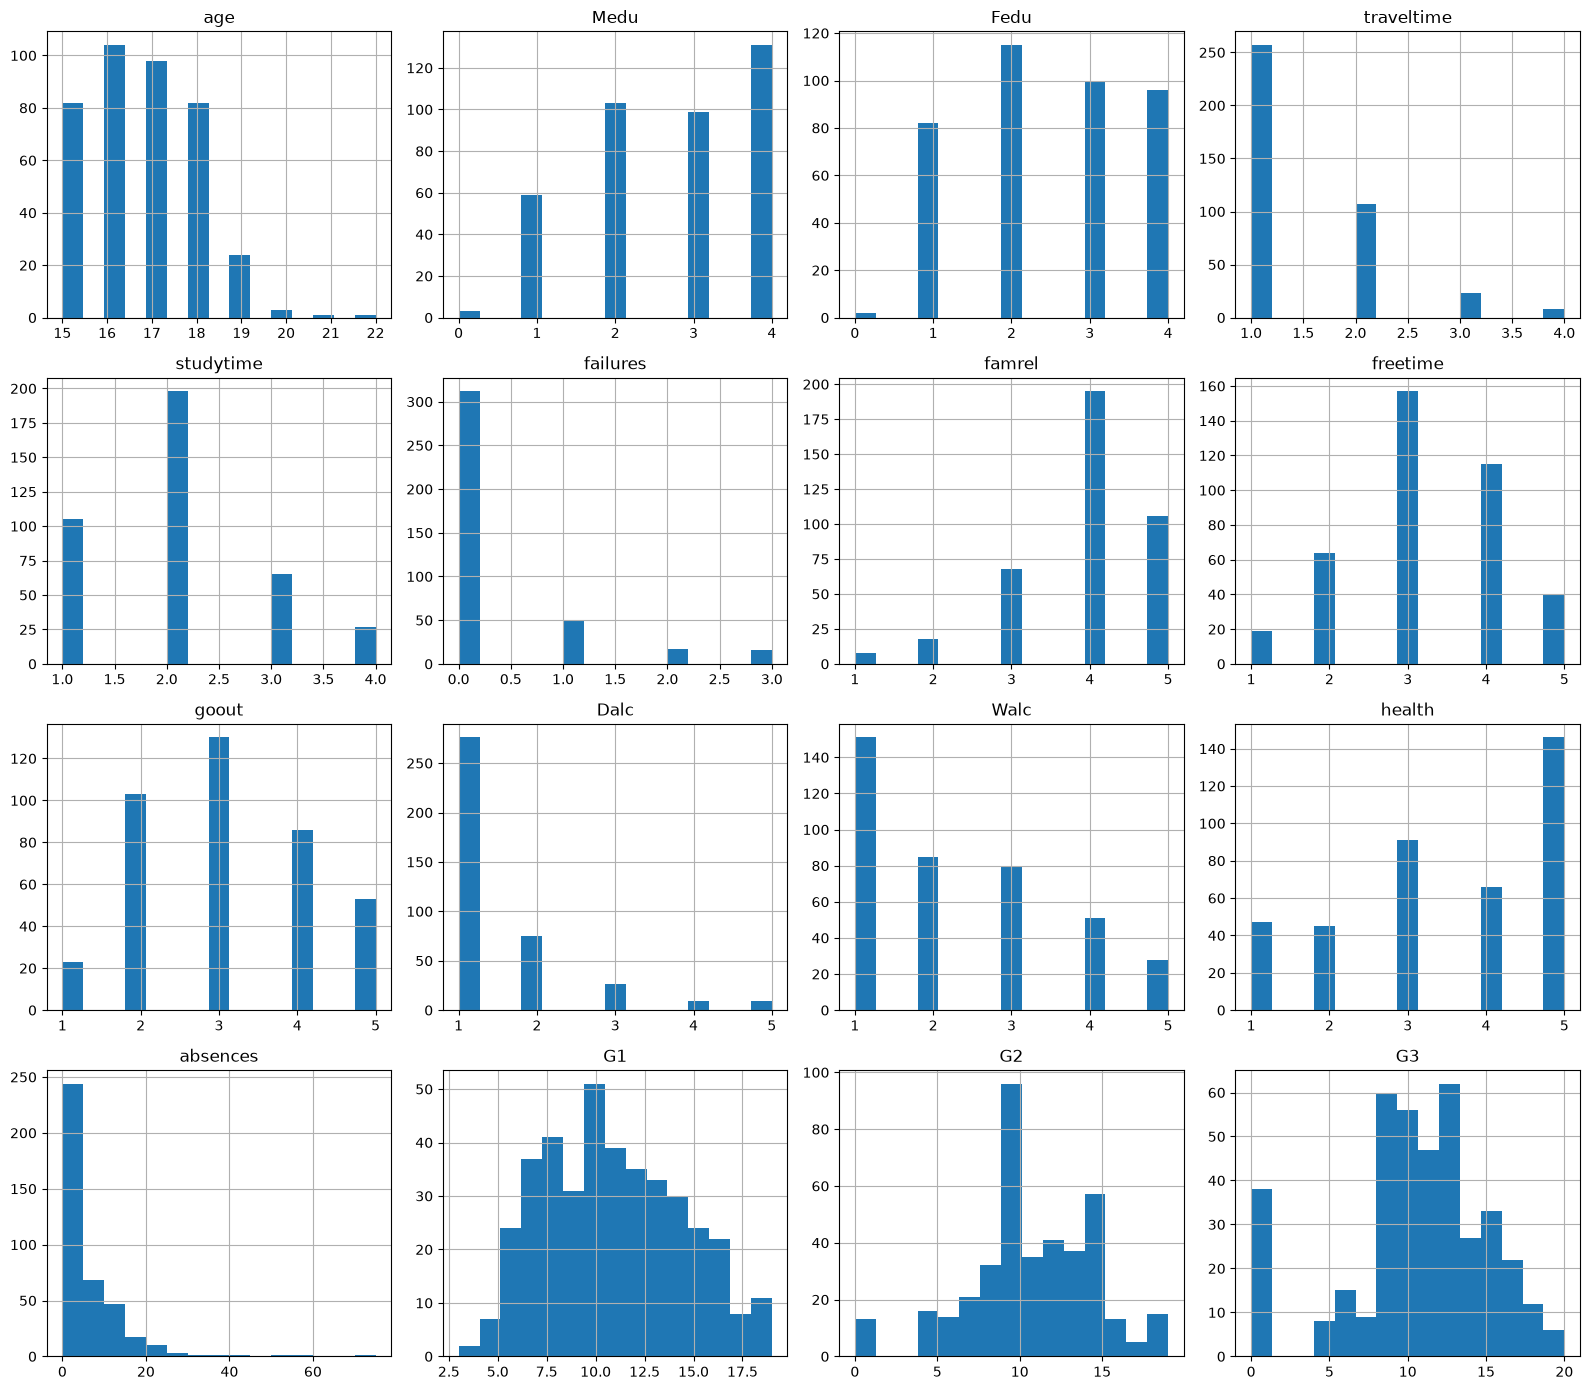

In [14]:
df[numeric_columns].hist(
    figsize=(16, 14),
    bins=15
)

plt.tight_layout()
plt.show()

In [15]:
def detect_outliers_iqr(data, columns):
    results = []

    for column in columns:
        Q1 = data[column].quantile(0.25)
        Q3 = data[column].quantile(0.75)

        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = data[
            (data[column] < lower_bound) |
            (data[column] > upper_bound)
        ]

        results.append({
            "Feature": column,
            "Q1": Q1,
            "Q3": Q3,
            "IQR": IQR,
            "Lower Bound": lower_bound,
            "Upper Bound": upper_bound,
            "Outlier Count": len(outliers)
        })

    return pd.DataFrame(results)


outlier_summary = detect_outliers_iqr(
    df,
    numeric_columns
)

outlier_summary

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,age,16.0,18.0,2.0,13.0,21.0,1
1,Medu,2.0,4.0,2.0,-1.0,7.0,0
2,Fedu,2.0,3.0,1.0,0.5,4.5,2
3,traveltime,1.0,2.0,1.0,-0.5,3.5,8
4,studytime,1.0,2.0,1.0,-0.5,3.5,27
5,failures,0.0,0.0,0.0,0.0,0.0,83
6,famrel,4.0,5.0,1.0,2.5,6.5,26
7,freetime,3.0,4.0,1.0,1.5,5.5,19
8,goout,2.0,4.0,2.0,-1.0,7.0,0
9,Dalc,1.0,2.0,1.0,-0.5,3.5,18


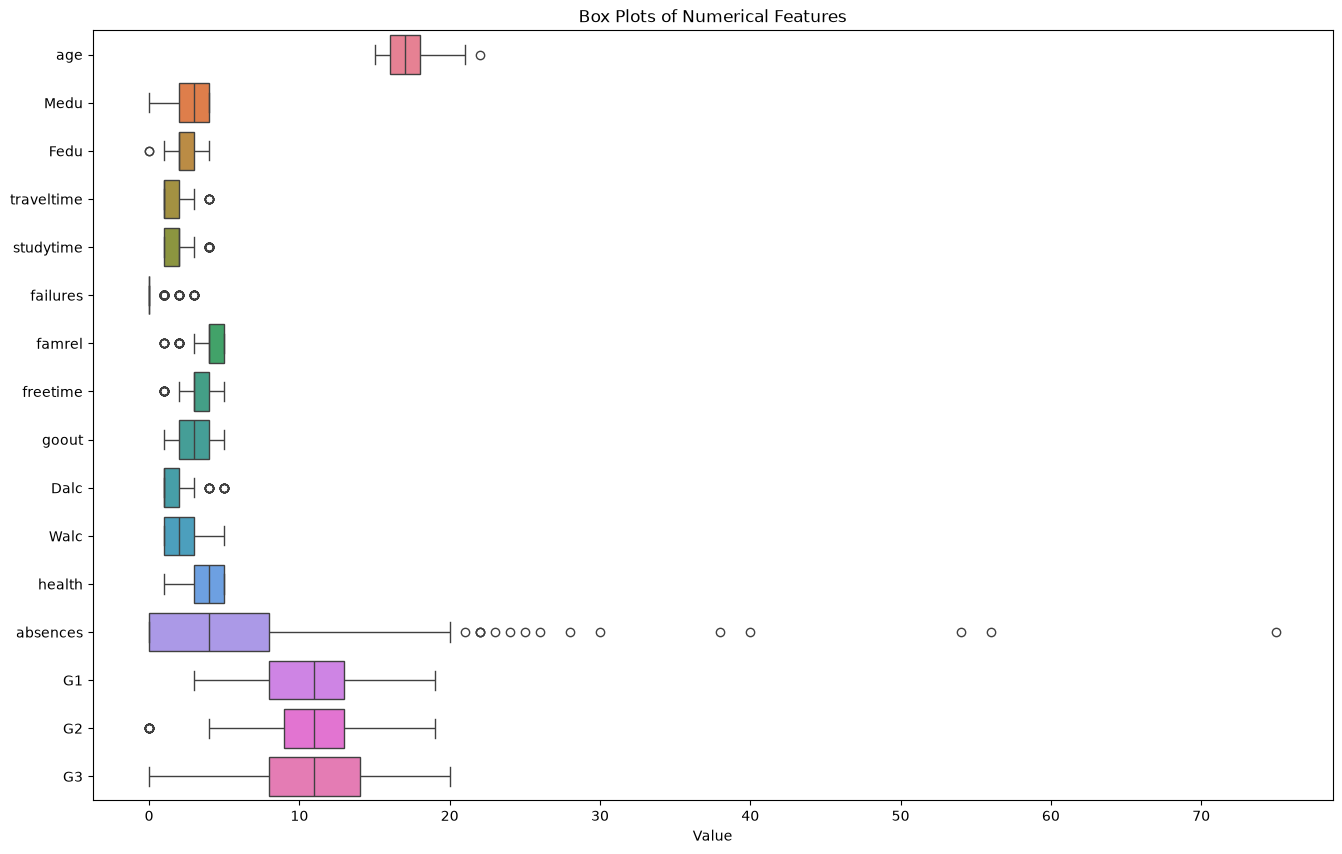

In [16]:
plt.figure(figsize=(16, 10))

sns.boxplot(
    data=df[numeric_columns],
    orient="h"
)

plt.title("Box Plots of Numerical Features")
plt.xlabel("Value")

plt.show()

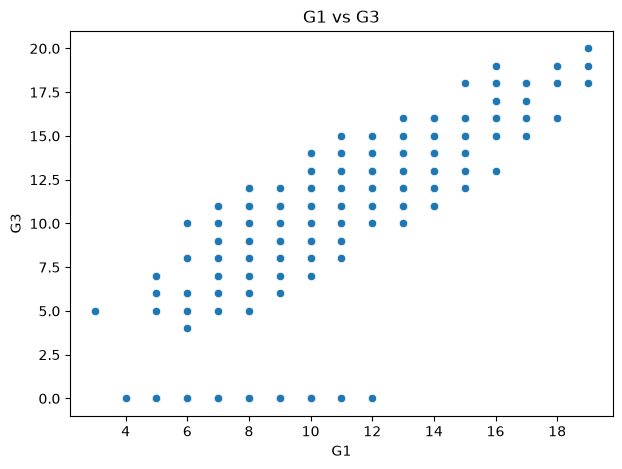

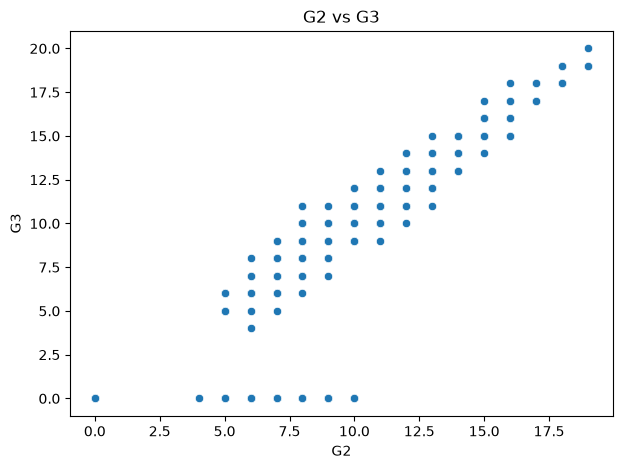

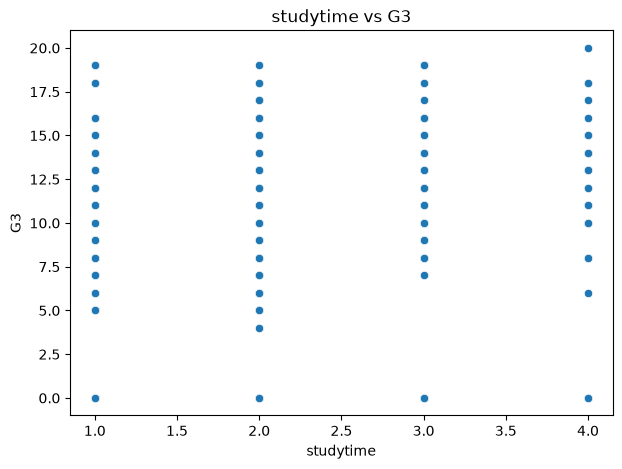

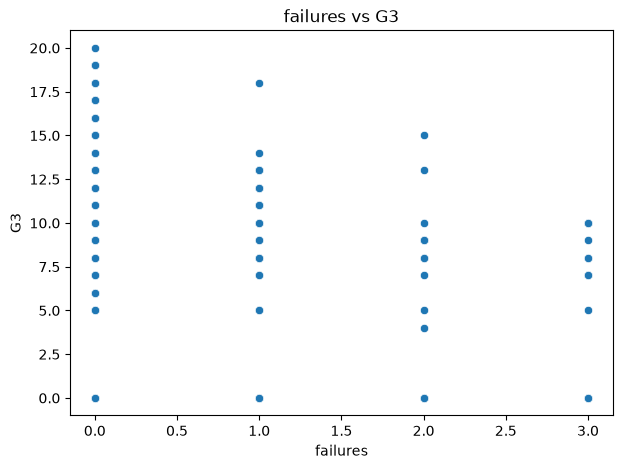

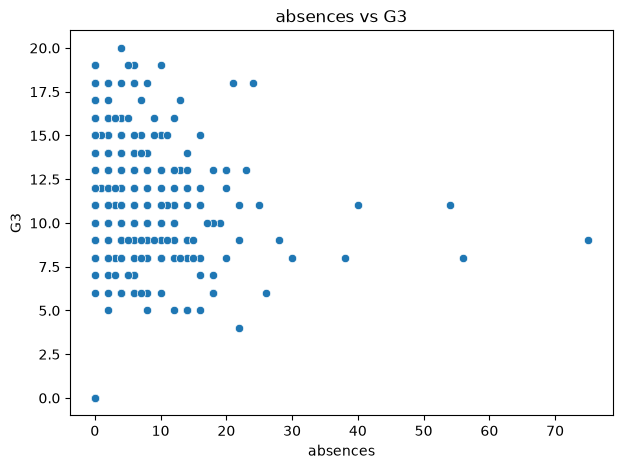

In [17]:
features = ["G1", "G2", "studytime", "failures", "absences"]

for feature in features:

    plt.figure(figsize=(7, 5))

    sns.scatterplot(
        data=df,
        x=feature,
        y="G3"
    )

    plt.title(f"{feature} vs G3")
    plt.xlabel(feature)
    plt.ylabel("G3")

    plt.show()

In [18]:
correlation = df[numeric_columns].corr()

correlation

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
age,1.000000,-0.163658,-0.163438,0.070641,-0.004140,0.243665,0.053940,0.016434,0.126964,0.131125,0.117276,-0.062187,0.175230,-0.064081,-0.143474,-0.161579
Medu,-0.163658,1.000000,0.623455,-0.171639,0.064944,-0.236680,-0.003914,0.030891,0.064094,0.019834,-0.047123,-0.046878,0.100285,0.205341,0.215527,0.217147
Fedu,-0.163438,0.623455,1.000000,-0.158194,-0.009175,-0.250408,-0.001370,-0.012846,0.043105,0.002386,-0.012631,0.014742,0.024473,0.190270,0.164893,0.152457
traveltime,0.070641,-0.171639,-0.158194,1.000000,-0.100909,0.092239,-0.016808,-0.017025,0.028540,0.138325,0.134116,0.007501,-0.012944,-0.093040,-0.153198,-0.117142
studytime,-0.004140,0.064944,-0.009175,-0.100909,1.000000,-0.173563,0.039731,-0.143198,-0.063904,-0.196019,-0.253785,-0.075616,-0.062700,0.160612,0.135880,0.097820
failures,0.243665,-0.236680,-0.250408,0.092239,-0.173563,1.000000,-0.044337,0.091987,0.124561,0.136047,0.141962,0.065827,0.063726,-0.354718,-0.355896,-0.360415
famrel,0.053940,-0.003914,-0.001370,-0.016808,0.039731,-0.044337,1.000000,0.150701,0.064568,-0.077594,-0.113397,0.094056,-0.044354,0.022168,-0.018281,0.051363
freetime,0.016434,0.030891,-0.012846,-0.017025,-0.143198,0.091987,0.150701,1.000000,0.285019,0.209001,0.147822,0.075733,-0.058078,0.012613,-0.013777,0.011307
goout,0.126964,0.064094,0.043105,0.028540,-0.063904,0.124561,0.064568,0.285019,1.000000,0.266994,0.420386,-0.009577,0.044302,-0.149104,-0.162250,-0.132791
Dalc,0.131125,0.019834,0.002386,0.138325,-0.196019,0.136047,-0.077594,0.209001,0.266994,1.000000,0.647544,0.077180,0.111908,-0.094159,-0.064120,-0.054660


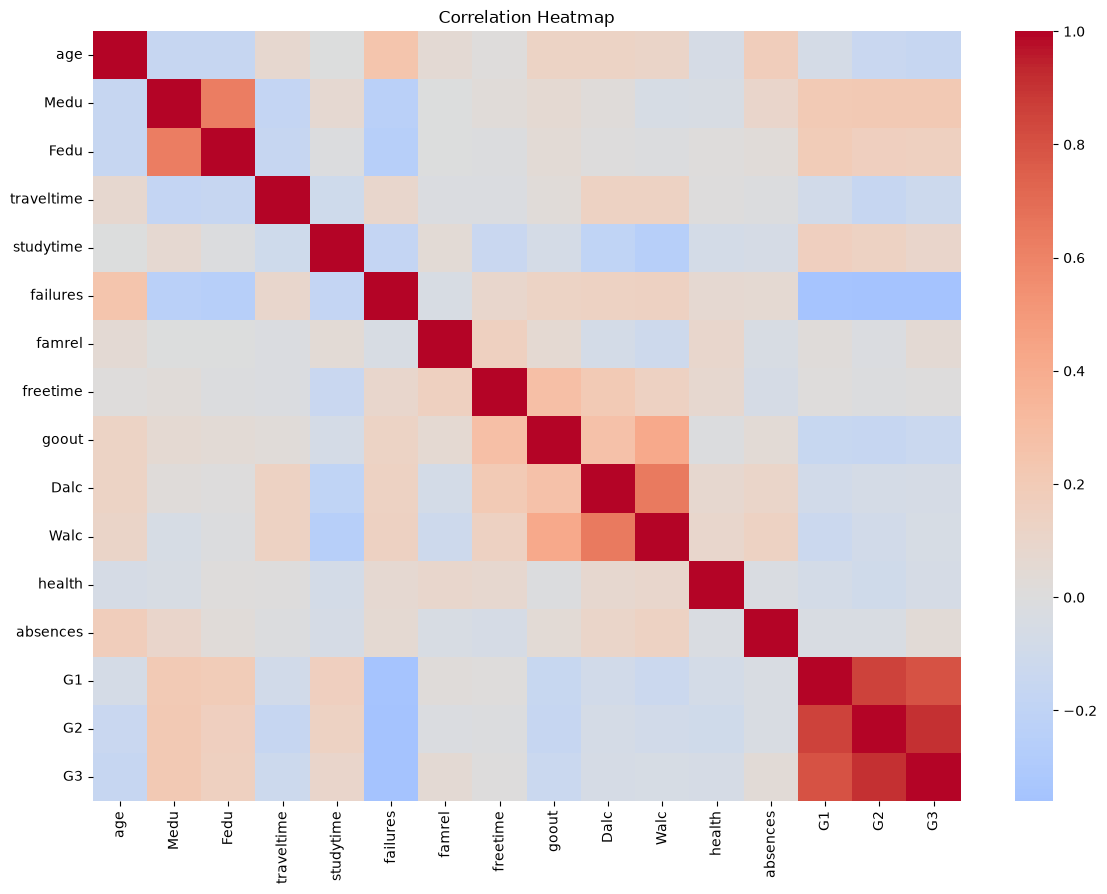

In [19]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation,
    annot=False,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

In [20]:
target_correlation = (
    correlation["G3"]
    .sort_values(ascending=False)
)

target_correlation

G3            1.000000
G2            0.904868
G1            0.801468
Medu          0.217147
Fedu          0.152457
studytime     0.097820
famrel        0.051363
absences      0.034247
freetime      0.011307
Walc         -0.051939
Dalc         -0.054660
health       -0.061335
traveltime   -0.117142
goout        -0.132791
age          -0.161579
failures     -0.360415
Name: G3, dtype: float64

In [21]:
for column in categorical_columns:

    print("\n", column)

    print(
        df[column]
        .value_counts()
    )


 school
school
GP    349
MS     46
Name: count, dtype: int64

 sex
sex
F    208
M    187
Name: count, dtype: int64

 address
address
U    307
R     88
Name: count, dtype: int64

 famsize
famsize
GT3    281
LE3    114
Name: count, dtype: int64

 Pstatus
Pstatus
T    354
A     41
Name: count, dtype: int64

 Mjob
Mjob
other       141
services    103
at_home      59
teacher      58
health       34
Name: count, dtype: int64

 Fjob
Fjob
other       217
services    111
teacher      29
at_home      20
health       18
Name: count, dtype: int64

 reason
reason
course        145
home          109
reputation    105
other          36
Name: count, dtype: int64

 guardian
guardian
mother    273
father     90
other      32
Name: count, dtype: int64

 schoolsup
schoolsup
no     344
yes     51
Name: count, dtype: int64

 famsup
famsup
yes    242
no     153
Name: count, dtype: int64

 paid
paid
no     214
yes    181
Name: count, dtype: int64

 activities
activities
yes    201
no     194
Name: count, dty

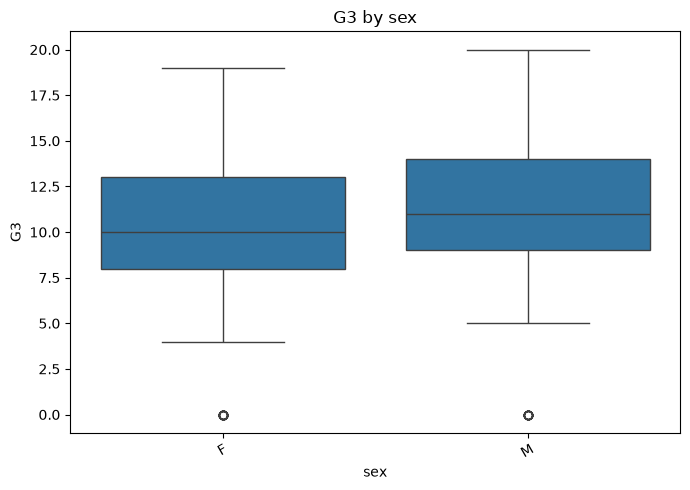

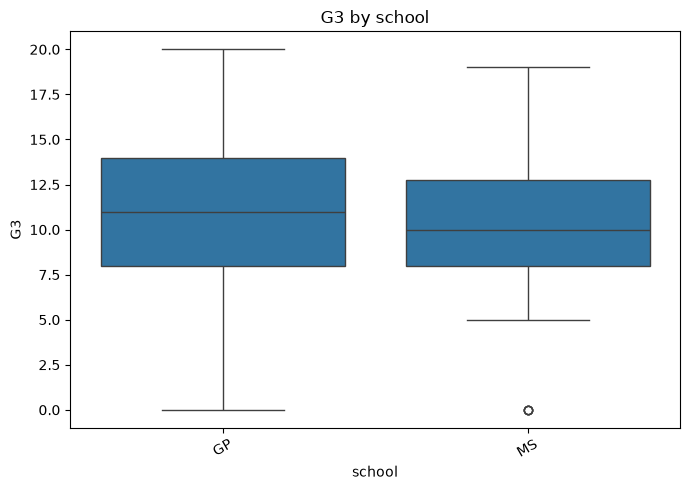

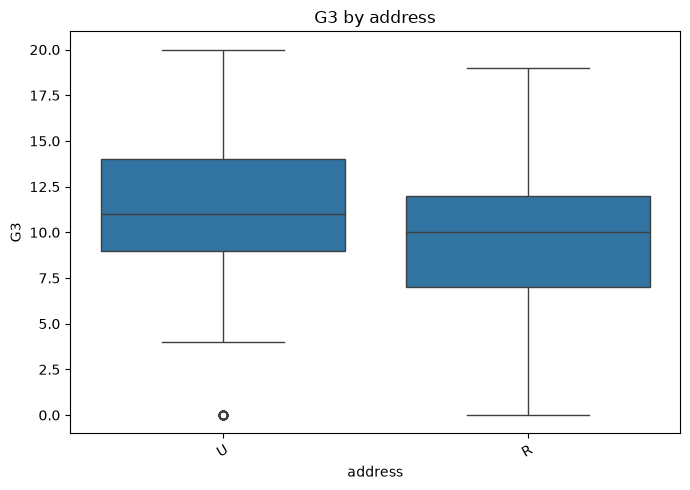

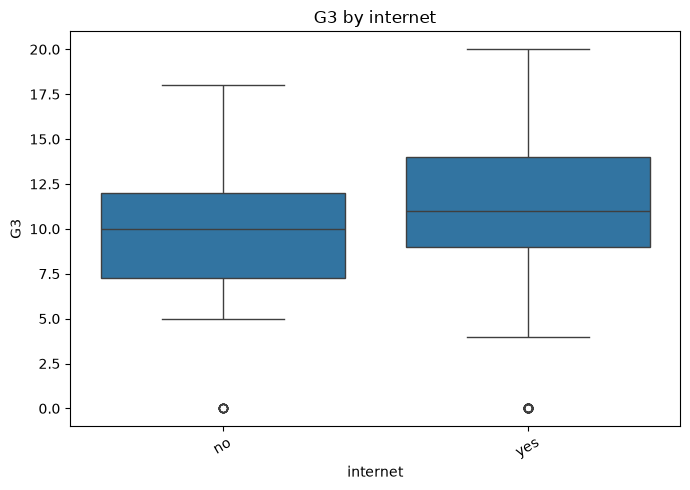

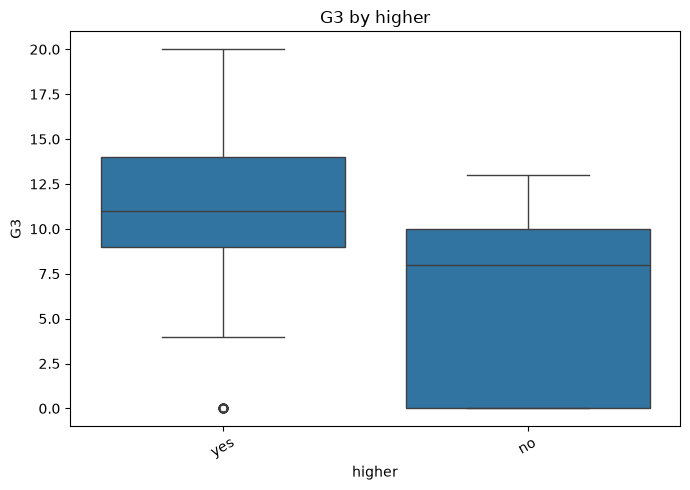

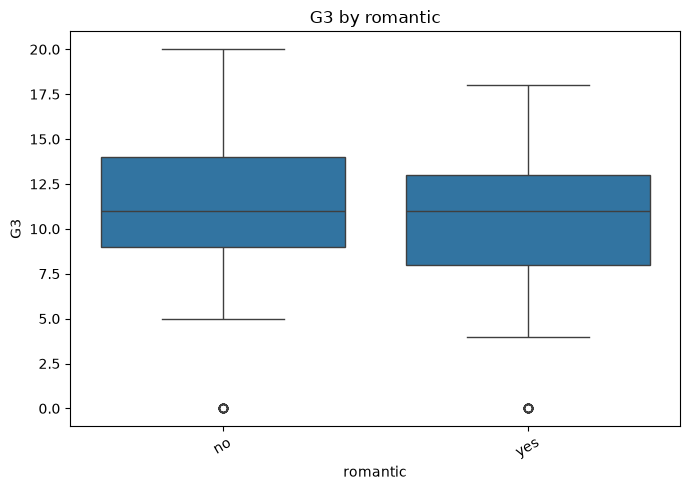

In [22]:
categorical_features = [
    "sex",
    "school",
    "address",
    "internet",
    "higher",
    "romantic"
]

for feature in categorical_features:

    plt.figure(figsize=(7, 5))

    sns.boxplot(
        data=df,
        x=feature,
        y="G3"
    )

    plt.title(f"G3 by {feature}")

    plt.xticks(rotation=30)

    plt.tight_layout()

    plt.show()

In [23]:
X = df.drop(columns=["G3"])
y = df["G3"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (395, 32)
Target shape: (395,)


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (316, 32)
Testing data: (79, 32)


In [25]:
numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_train.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']

Categorical features:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


In [26]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [27]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

In [28]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [29]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print(
    "Original training shape:",
    X_train.shape
)

print(
    "Processed training shape:",
    X_train_processed.shape
)

print(
    "Original testing shape:",
    X_test.shape
)

print(
    "Processed testing shape:",
    X_test_processed.shape
)

Original training shape: (316, 32)
Processed training shape: (316, 58)
Original testing shape: (79, 32)
Processed testing shape: (79, 58)


# Conclusion

The dataset was explored systematically to understand its structure, data types, distributions, missing values, duplicates, outliers, correlations, and relationships with the target variable.

The preprocessing strategy separates numerical and categorical features. Numerical features are handled using median imputation and standardization, while categorical features are handled using most-frequent imputation and one-hot encoding.

The preprocessing transformations are fitted only on the training data and then applied to the test data. This prevents information from the test set from influencing the preprocessing process and reduces the risk of data leakage.

The resulting processed dataset provides a consistent foundation for the Week 3 model development and training stage.